In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("mnist_train.csv", header=None)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
h*w*c=20*106


0--255

RGB

In [54]:
28*28*1

784

In [9]:
df.iloc[0,1:].values.reshape(28,28)

array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0

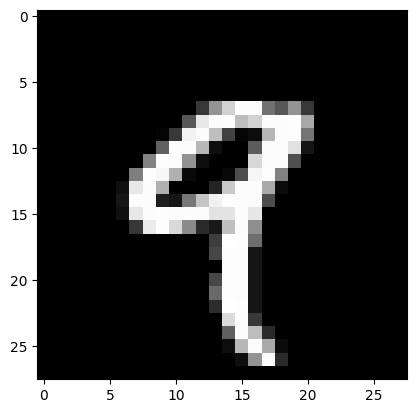

In [55]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[4,1:].values.reshape(28,28), cmap="gray")

In [11]:
x = df.iloc[:, 1:]
x.shape

(44199, 784)

In [14]:
x.fillna(0, inplace=True)

In [15]:
x.isnull().sum()

,0
1,0
2,0
3,0
4,0
5,0
...,...
780,0
781,0
782,0
783,0


In [56]:
from sklearn.decomposition import PCA
model = PCA(n_components=0.95)
x1 = model.fit_transform(x)

In [32]:
784-154

630

In [58]:
x1.shape

(44199, 154)

In [33]:
# dir(model)

In [59]:
np.sum(model.explained_variance_ratio_)

np.float64(0.9503745812647221)

In [60]:
import numpy as np
np.round(model.explained_variance_ratio_,2)

array([0.1 , 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03, 0.03, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.

In [61]:
column = ["PC"+str(i) for i in range(154)]

In [62]:
x2 = pd.DataFrame(x1, columns=column)

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [65]:
y = df.iloc[:, 0]

In [75]:
xtrain, xtest, ytrain, ytest = train_test_split(x2, y, test_size=0.2, random_state=5)

In [76]:
m1 = LogisticRegression()
m1.fit(xtrain, ytrain) #fit=learn, transform=apply

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [77]:
ypred = m1.predict(xtest)

In [82]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(ytest, ypred)

0.9063348416289593

In [84]:
xtest.shape

(8840, 154)

In [83]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       846
           1       0.92      0.96      0.94       993
           2       0.91      0.87      0.89       905
           3       0.91      0.88      0.90       929
           4       0.90      0.92      0.91       811
           5       0.85      0.87      0.86       769
           6       0.93      0.95      0.94       890
           7       0.91      0.92      0.92       934
           8       0.89      0.84      0.87       872
           9       0.88      0.88      0.88       891

    accuracy                           0.91      8840
   macro avg       0.91      0.91      0.91      8840
weighted avg       0.91      0.91      0.91      8840



In [73]:
xtrain.head()

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC144,PC145,PC146,PC147,PC148,PC149,PC150,PC151,PC152,PC153
29777,-333.060711,432.033074,-415.362511,603.868377,184.727614,-171.548197,-120.187853,-177.803515,-193.110869,311.660609,...,-23.443613,46.895937,-39.191412,15.767146,40.116571,-43.642331,29.377737,19.444056,33.930069,27.717370
42936,-148.381844,639.245254,317.967721,87.628929,29.138179,-508.912571,-196.407832,-436.442250,-366.855472,92.871915,...,53.237059,-73.298429,-14.658867,42.970024,36.961962,-4.634862,-16.646993,-8.007860,88.605289,12.939543
1311,-198.187883,34.969638,-760.505965,13.380898,-156.882953,152.583308,119.906874,14.351623,315.721217,-477.147862,...,-23.056282,-19.784973,-8.412472,-28.733433,59.536347,-49.455223,-45.164354,65.134428,-0.338210,34.921334
5356,-368.032543,-700.044357,199.626752,-5.856248,191.612223,-159.635545,-144.040323,-304.705913,-406.314175,-343.787576,...,-37.214860,62.784941,-10.093999,-19.360594,12.075594,16.263803,15.765348,24.364833,-11.744995,3.103920
25066,-36.488482,-234.976209,-505.466155,313.944875,-167.599257,385.604547,-59.715155,533.413708,171.934344,-241.417187,...,-0.458504,-48.934082,25.746329,-31.726865,-27.109835,-60.421725,-56.574578,11.003237,3.167263,-117.428109


In [ ]:
xtrain

<Axes: >

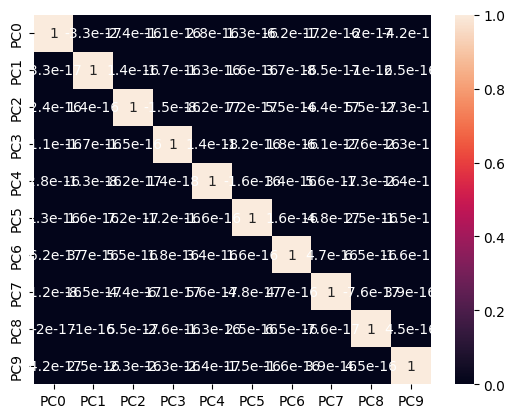

In [52]:
import seaborn as sns
sns.heatmap(x2.corr(), annot=True)

In [53]:
x2.var()

,0
PC0,335497.850293
PC1,242958.371782
PC2,214392.603587
PC3,185805.663168
PC4,166786.852592
PC5,149785.785727
PC6,112793.355150
PC7,99326.956369
PC8,95164.711815
PC9,81178.150845
